In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from stoch_imp import *
import os

/home/bmeeus/PycharmProjects/stoch_imp/stoch_imp/WMatrix.py:161: SyntaxWarning: invalid escape sequence '\s'
  """
/home/bmeeus/PycharmProjects/stoch_imp/stoch_imp/WMatrix.py:241: SyntaxWarning: invalid escape sequence '\s'
  """
/home/bmeeus/PycharmProjects/stoch_imp/stoch_imp/WMatrix.py:269: SyntaxWarning: invalid escape sequence '\s'
  """


In [3]:
n_iter = range(2, 51, 2)
om_arr = [0.01]
len_n = len(list(n_iter))
len_sd = 3
results = np.zeros([len_n, len_sd])
mu = sp.Symbol("mu", real=True)
muEq = 0
# for n in n_iter:
for n in [24]:
    for sd in [1 ]:
        w = WMatrix(n + 1, zi=True, eq=muEq, ds=mu, )

        en_arr = np.random.normal(0, sd, n)

        for i in range(1, n):
            w.add_trans(i, i + 1, np.exp((en_arr[i] - en_arr[i-1])/2))
        w.add_trans(0, n, 1/(1+ np.exp(- (en_arr[-1]))), ri=1 - 1/(1+ sp.exp(- (en_arr[-1]))))
        w.add_trans(0, 1, 1 / (1 + sp.exp(en_arr[0]-mu)), ri=1 - 1 / (1 + sp.exp(en_arr[0]-mu)))
        w.to_num()
        w.calc_weq()
        w.calc_w1()
        sp.pretty_print(w.weq)
        sp.pretty_print(w.w1)
        for ind, cond in w.get_conds([(n, 0)], normal=True):
            print(ind, sd)
            print(w.coeff)
            # res_arr = cond(om_arr)
            #
            # # plot result
            # D_x = max(np.real(res_arr)) - min(np.real(res_arr))
            # results[n, int(2*sd) ] = D_x

⎡-50578396277831841325992481723           200142697208369                      ↪
⎢───────────────────────────────          ───────────────                      ↪
⎢ 45014269720836900000000000000           450142697208369                      ↪
⎢                                                                              ↪
⎢        250000000000000          -90319100188353741012336931829          1000 ↪
⎢        ───────────────          ───────────────────────────────         ──── ↪
⎢        450142697208369           45014269720836900000000000000          1561 ↪
⎢                                                                              ↪
⎢                                         156183430062341          -9832006163 ↪
⎢               0                         ───────────────          ─────────── ↪
⎢                                         100000000000000           6100915236 ↪
⎢                                                                              ↪
⎢                           

In [6]:
for om in np.linspace(0.001, 0.1, 1000):
    print(om)
    print(cond(om))

0.001


OverflowError: int too large to convert to float

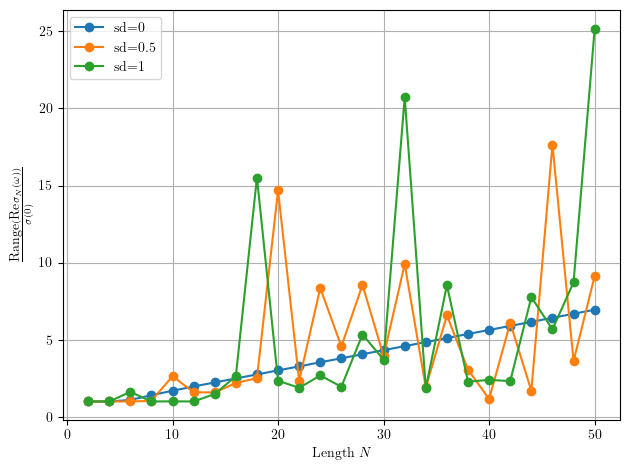

In [3]:
arr_0 = []
arr_05 = []
arr_1 = []
with open("res.csv", "r") as f:
    for line in f.readlines():
        line = line.strip().split(",")
        if line[1] == "0":
            arr_0.append(float(line[2]))
        elif line[1] == "0.5":
            arr_05.append(float(line[2]))
        else:
            arr_1.append(float(line[2]))

with create_fig(1, save_path="fig_rand.pdf") as (fig, ax):
    n_arr = list(range(2, 51, 2))
    ax.plot(n_arr, arr_0, marker='o', label=r"sd=0")
    ax.plot(n_arr, arr_05, marker='o', label=r"sd=0.5")
    ax.plot(n_arr, arr_1, marker='o', label=r"sd=1")
    ax.set_xlabel(r"Length $N$")
    ax.set_ylabel(r"$\frac{\textrm{Range}(\textrm{Re} \sigma_N (\omega))}{\sigma(0)}$")
    ax.grid(True)
    ax.legend()